[Introduction & System Selection]
This part of the project involves modeling a stiff RC circuit with fast transient. This is a system where the capacitor voltage is very quick compared to the input voltage. The governing ODE equation for this is as follows:

dV/dt = -(1/RC)V + (1/RC)V_source(t)

where 

V(t) = capacitor voltage
R = resistance
C = capacitance
V_source(t) = input voltage.

For this problem,

R = 100 ohms  
C = 10^-9 F  
RC = 10^-7 s  
V_source(t) = 5sin(t)

We can substitute these values to get

dV/dt = -10^7 V + 10^7(5sin(t))

This system is stiff because the circuit responds much faster than the input voltage (10^-7 seconds versus seconds). Because these time scales are so different, previous methods that were used such as Euler's Forward would require extremely small step sizes.

R = 100 ohms
C = 1e-09 F
RC = 1.0000000000000001e-07 s
lambda = 10000000.0
Estimated stiffness ratio = 10000000.0


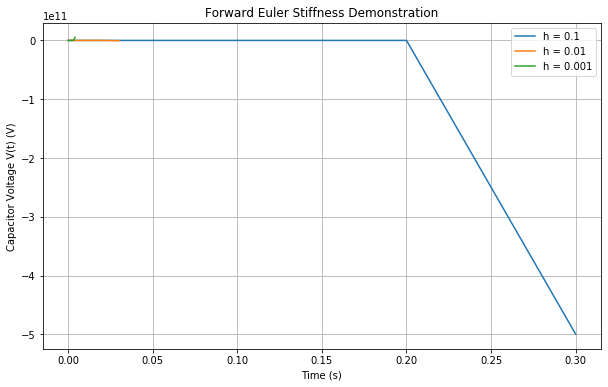

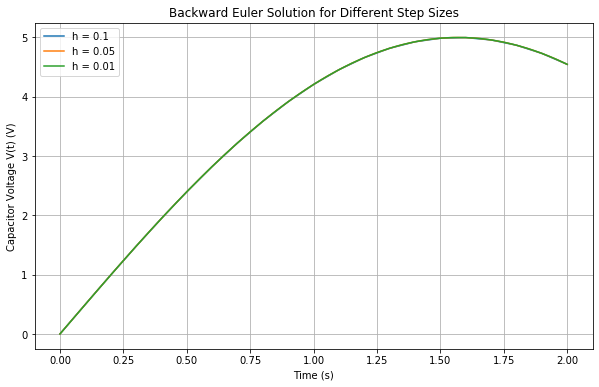

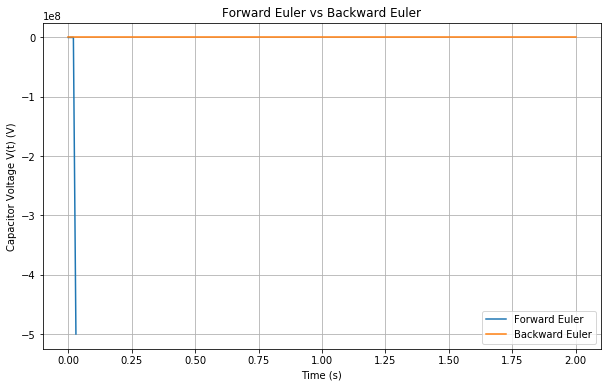

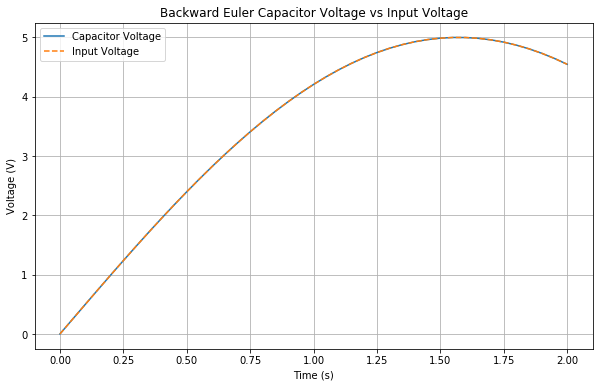

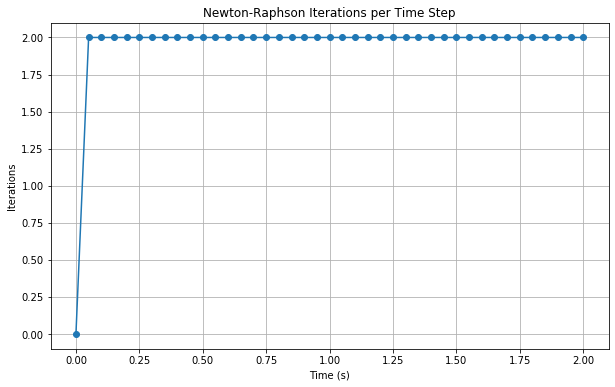


Forward Euler estimated stable step size: 1e-07
Forward Euler estimated number of steps: 20000000

Backward Euler Performance
h, steps, avg NR iterations, total NR iterations
0.1 20 2.0 40.0
0.05 40 2.0 80.0
0.01 200 2.0 400.0


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters ------------------------------------------------------------------

R = 100
C = 10**(-9)
RC = R * C
lam = 1 / RC
t_start = 0
t_end = 2
V_0 = 0 

print("R =", R, "ohms")
print("C =", C, "F")
print("RC =", RC, "s")
print("lambda =", lam)
print("Estimated stiffness ratio =", 1 / RC)


# Functions --------------------------------------------------------------------

def V_source(t):
    return 5 * np.sin(t)

def f(t, V):
    return -lam * V + lam * V_source(t)

def euler_forward(h, t_start, t_end, V_0):
    t_values = np.arange(t_start, t_end + h, h)
    V_values = np.zeros(len(t_values))

    V_values[0] = V_0

    for i in range(1, len(t_values)):
        t_n = t_values[i - 1]
        V_n = V_values[i - 1]

        V_values[i] = V_n + h * f(t_n, V_n)

        if abs(V_values[i]) > 1e6:
            return t_values[:i+1], V_values[:i+1]  #Prevents overflow

    return t_values, V_values

def g(V_next, V_current, t_next, h):
    return V_next - V_current - h * f(t_next, V_next)

def g_prime(h):
    return 1 + h * lam

def newton_raphson(V_current, t_next, h, tol=10**(-6), max_iter=20):
    V_guess = V_current

    for iteration in range(1, max_iter + 1):
        g_value = g(V_guess, V_current, t_next, h)
        g_prime_value = g_prime(h)

        V_new = V_guess - g_value / g_prime_value

        if abs(V_new - V_guess) < tol:
            return V_new, iteration

        V_guess = V_new

    return V_guess, max_iter

def euler_backward(h, t_start, t_end, V_0):
    t_values = np.arange(t_start, t_end + h, h)
    V_values = np.zeros(len(t_values))
    iteration_values = np.zeros(len(t_values))

    V_values[0] = V_0

    for i in range(1, len(t_values)):
        t_next = t_values[i]
        V_current = V_values[i - 1]

        V_values[i], iteration_values[i] = newton_raphson(V_current, t_next, h)

    return t_values, V_values, iteration_values

# Figure 1: Forward Euler stiffness demonstration ------------------------------

h_values_forward = [0.1, 0.01, 0.001]

plt.figure(figsize=(10, 6))

for h in h_values_forward:
    t_values, V_values = euler_forward(h, t_start, t_end, V_0)
    plt.plot(t_values, V_values, label=f"h = {h}")

plt.title("Forward Euler Stiffness Demonstration")
plt.xlabel("Time (s)")
plt.ylabel("Capacitor Voltage V(t) (V)")
plt.legend()
plt.grid()
plt.show()


# Figure 2: Backward Euler with different step sizes ---------------------------

h_values_backward = [0.1, 0.05, 0.01]

plt.figure(figsize=(10, 6))

for h in h_values_backward:
    t_values, V_values, iteration_values = euler_backward(h, t_start, t_end, V_0)
    plt.plot(t_values, V_values, label=f"h = {h}")

plt.title("Backward Euler Solution for Different Step Sizes")
plt.xlabel("Time (s)")
plt.ylabel("Capacitor Voltage V(t) (V)")
plt.legend()
plt.grid()
plt.show()


# Figure 3: Forward Euler vs Backward Euler ------------------------------------

h_compare = 0.01

t_forward, V_forward = euler_forward(h_compare, t_start, t_end, V_0)
t_backward, V_backward, iterations_backward = euler_backward(h_compare, t_start, t_end, V_0)

plt.figure(figsize=(10, 6))
plt.plot(t_forward, V_forward, label="Forward Euler")
plt.plot(t_backward, V_backward, label="Backward Euler")

plt.title("Forward Euler vs Backward Euler")
plt.xlabel("Time (s)")
plt.ylabel("Capacitor Voltage V(t) (V)")
plt.legend()
plt.grid()
plt.show()


# Figure 4: Backward Euler vs input voltage ------------------------------------

h = 0.05

t_values, V_values, iteration_values = euler_backward(h, t_start, t_end, V_0)
input_values = V_source(t_values)

plt.figure(figsize=(10, 6))
plt.plot(t_values, V_values, label="Capacitor Voltage")
plt.plot(t_values, input_values, "--", label="Input Voltage")

plt.title("Backward Euler Capacitor Voltage vs Input Voltage")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid()
plt.show()


# Figure 5: Newton-Raphson iterations per step ---------------------------------

plt.figure(figsize=(10, 6))
plt.plot(t_values, iteration_values, "o-")

plt.title("Newton-Raphson Iterations per Time Step")
plt.xlabel("Time (s)")
plt.ylabel("Iterations")
plt.grid()
plt.show()


# Performance table ------------------------------------------------------------

stable_forward_h = 1e-7
forward_steps_needed = int((t_end - t_start) / stable_forward_h)

print("Forward Euler estimated stable step size:", stable_forward_h)
print("Forward Euler estimated number of steps:", forward_steps_needed)

print("Backward Euler Performance")
print("h, steps, avg NR iterations, total NR iterations")

for h in h_values_backward:
    t_values, V_values, iteration_values = euler_backward(h, t_start, t_end, V_0)

    steps = len(t_values) - 1
    avg_iterations = np.mean(iteration_values[1:])
    total_iterations = np.sum(iteration_values)

    print(h, steps, avg_iterations, total_iterations)

[Demonstration of Stiffness]

The circuit's stiffness can be demonstrated with Euler's Forward by applying it to the governing equation. Such method utilizes

V_{n+1} = V_n + h f(t_n, V_n)

to progress the solution. However, this method quickly becomes unstable and diverges with higher step sizes. This results in a skewed approximation that does not accurately measure the data. The stiffness of the system depends primarily on the ratio between the circuit's and voltage's response times. Since the circuit responds on a timescale of 10^-7 seconds and the voltage of 1 second, the resulting stiffness ratio of 10^7 becomes quite apparent. The ratio makes Euler's Forward require extremely small step sizes, which is computationally impractical. The inconvenience of such methods make implicit methods like Backward Euler much more enticing for stiff problems.

[Mathematical Setup]
The Backward Euler (an implicit method) for this problem is

V_(n+1) = V_n + h f(t_(n+1), V_(n+1))

Where

f(t, V) = -10^7 V + 5 * 10^7 * sin(t)

This can be substituted into the equation to get.

V_(n+1) = V_n + h(-10^7 V_(n+1) + 5* 10^7 * sin(t_(n+1)))

The residual function for the problem is defined as

g(V_(n+1)) = V_(n+1) - V_n - h(-10^7 V_(n+1) + 5 * 10^7 * sin(t_(n+1)))

Now, the Newton-Raphson iteration is used to solve for V_(n+1) using

V^(k+1) = V^k - g(V^k)/g'(V^k)

where its derivative is

g'(V_(n+1)) = 1 + h(10^7)

Since its derivative is constant and thus converges quickly, the Newton-Raphson method is a good choice for this problem.

[Implementation]
This system was implemented in order to compare both Euler's Forward and Backward methods. The Forward was shown to be unstable when modeling the stiff system, and the Backward utilized the Newton-Raphson iteration to solve the implicit equation at each step; thus, Backward Euler demonstrated much more stability in this problem. The code provides the required functions to include the residual (and its derivative), the Newton-Raphson, and the ODE itself. Graphs were shown to demonstrate not only the insability of the Forward method but also the stability of the Backward's method regardless of step size.

[Results & Analysis]
The diverging solution for the Euler's Forward method produces unnatural behavior in the physical scenario; this makes it a poor candidate to model stiff systems. The results show an apparent contrast with Backwards Euler however. The implicit method remained stable at all step sizes, and the solutions for each size closely overlapped. This indicates that Backward Euler is not nearly as sensitive to step size as Forward is, and it models the natural behavior of the capacitor voltage closely following the input voltage. This is expected behavior due to the extremely fast nature of the system.

These notions are additionally supported by the comparison and Newton-Raphson plots. Euler's forward is seen to diverge quickly, while the Backward method remains stable for the duration of the time period. The iteration plot also demonstrated that the Backward Euler converged quickly, only needing two iterations per step. As previously mentioned, the Backward Euler modeling is a much more effective method to model stiff systems.

[Performance Analysis]
The performance of each method lies in their stability, step sizes, and computational costs. As previously mentioned, Euler's forward requires an impractically small step size to be somewhat stable for this stiff circuit. The silver lining for the method however is that the single function evaluation per step keeps the computational costs to a minimum.

The Backward Euler has an increased computational cost per step due to its reliance on the Newton-Raphson iteration to solve the implicit equation. However, the requirement of about two iterations per step enabled the function to converge quickly. This resulted in a stable method for this stiff problem. Additionally, the stability at larger step sizes enables Backward Euler to have less total steps than Euler's Forward. Overall, the Backward Euler method is the best pick for this problem.

[Conclusions]
The data and graphs make it clear that Backward Euler is the premier method to model stiff systems. It remains stable at various step sizes and produces realilistic results that do not diverge. There is a larger computational cost per step of the Backward as oppose to Euler's Forward; however, that cost is ultimately negated buy utilizing larger step sizes (that Forward can not handle) to minimize the overall computation time. This is supported by the fact that Forward Euler requires impractically small step sizes in order to remain stable. This portion of the project highlights the importance of selecting the appropriate modeling method when analyzing stiff systems, where traditionally fesible methods such as Euler's Forward are rendered impractical. Implicit methods, such as Backward Euler, can handle the drastically varying time scales and are thus conditioned to solve stiff systems.